In [1]:
import dynamo as dyn
import matplotlib.pyplot as plt
import numpy as np
dyn.configuration.set_figure_params('dynamo', background='white')

/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/an

In [2]:
dyn.configuration.set_pub_style_mpltex()
dyn.pl.style()



 ███                               ████████        
█████   █████    █████    █████    ███   █████      
   ██████   ██████   ██████   ████████      ████ 
  ___                           ████            ███
 |   \ _  _ _ _  __ _ _ __  ___                 ███
 | |) | || | ' \/ _` | '  \/ _ \█████           ███ 
 |___/ \_, |_||_\__,_|_|_|_\___/█████       ████  
       |__/                        ███   █████     
Tutorial: https://dynamo-release.readthedocs.io/       
                                     █████      



In [3]:
adata = dyn.sample_data.hematopoiesis()

|-----> Downloading processed hematopoiesis adata
|-----> Downloading data to ./data/hematopoiesis.h5ad
|-----> File ./data/hematopoiesis.h5ad already exists.


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering cell_type by stack threshold when stacking color because it is not a numeric type


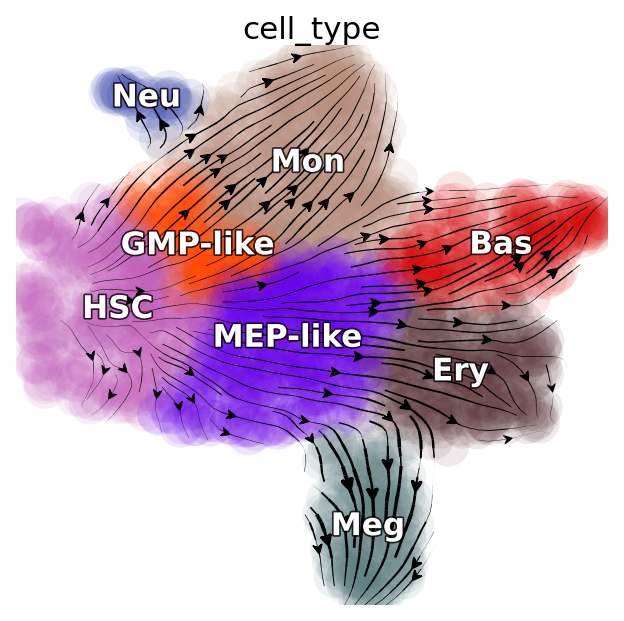

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> plotting with basis key=X_umap


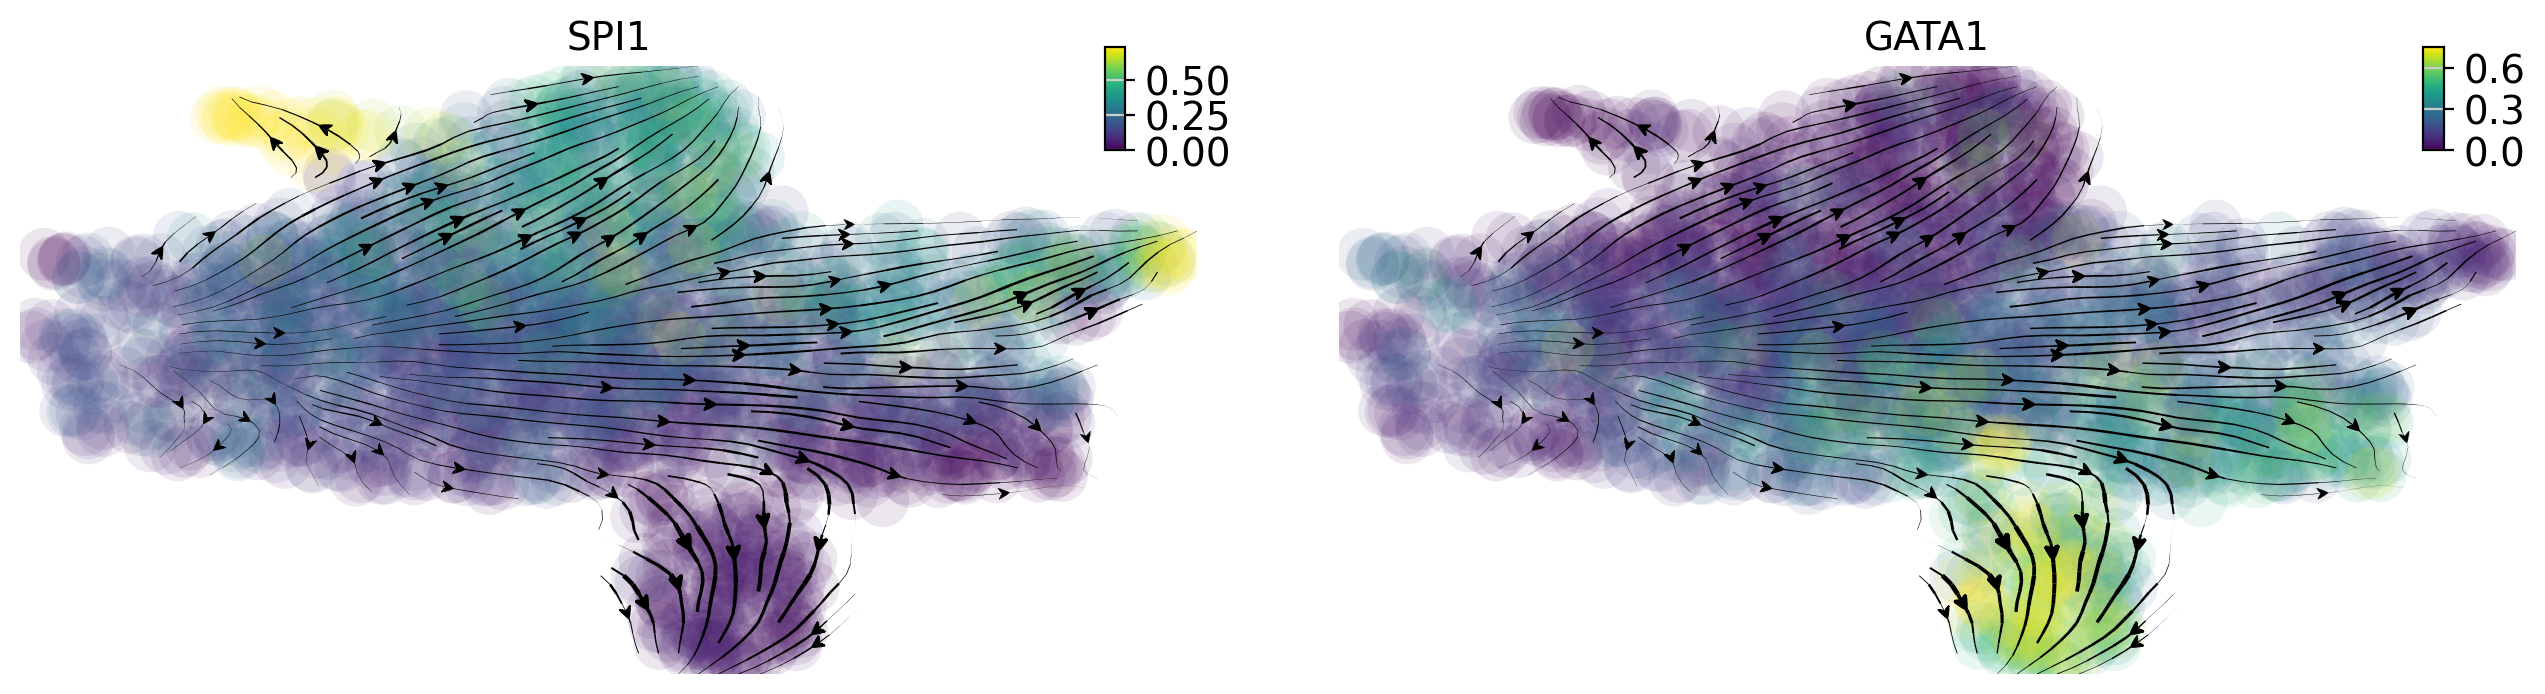

In [4]:
%matplotlib inline
dyn.pl.style()
dyn.pl.streamline_plot(
    adata,
    color=["cell_type"],
    layer="M_t",
    figsize=(4, 4),
    ncols=2
)
dyn.pl.style()
dyn.pl.streamline_plot(
    adata,
    color=["SPI1", "GATA1"],
    layer="M_t",
    figsize=(8, 4),
    ncols=2
)


In [5]:
dyn.pl.streamline_plot?

Signature:
dyn.pl.streamline_plot(
    adata: anndata._core.anndata.AnnData,
    basis: str = 'umap',
    x: int = 0,
    y: int = 1,
    ekey: str = 'M_s',
    vkey: str = 'velocity_S',
    color: Union[str, List[str]] = 'ntr',
    layer: str = 'X',
    highlights: Optional[list] = None,
    labels: Optional[list] = None,
    values: Optional[list] = None,
    theme: Optional[Literal['blue', 'red', 'green', 'inferno', 'fire', 'viridis', 'darkblue', 'darkred', 'darkgreen']] = None,
    cmap: Optional[str] = None,
    color_key: Union[Dict[str, str], List[str], NoneType] = None,
    color_key_cmap: Optional[str] = None,
    background: Optional[str] = 'white',
    ncols: int = 4,
    pointsize: Optional[float] = None,
    figsize: Tuple[float, float] = (6, 4),
    show_legend: str = 'on data',
    use_smoothed: bool = True,
    ax: Optional[matplotlib.axes._axes.Axes] = None,
    sort: Literal['raw', 'abs', 'neg'] = 'raw',
    aggregate: Optional[str] = None,
    show_arrowed_spines: bo

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering cell_type by stack threshold when stacking color because it is not a numeric type


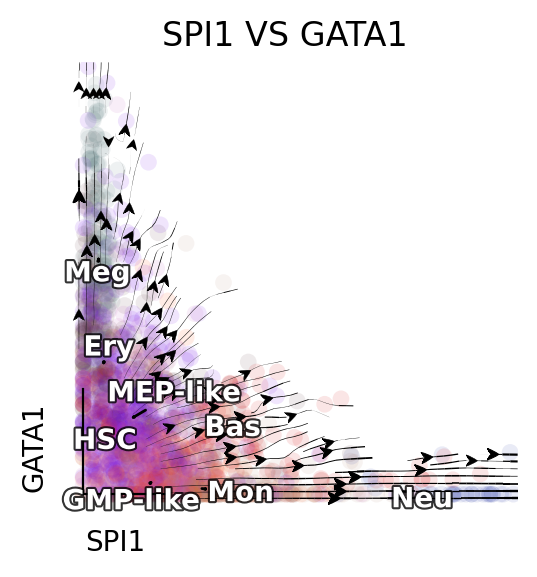

In [6]:
%matplotlib inline
#dyn.pl.style()
fig,ax=plt.subplots(1,1,figsize = (3,3))
dyn.pl.streamline_plot(
    adata,
    color="cell_type",
    x="SPI1",
    y="GATA1",
    layer="M_t",
    ekey="M_t",
    pointsize=0.1,
    alpha=1,
    vkey="velocity_alpha_minus_gamma_s",
    s_kwargs_dict={'adjust_legend':True,
                                     },
                       linewidth=0.5,
                       #show_arrowed_spines=True,
                      save_show_or_return='return',ax=ax
)

coords=adata[:,['SPI1','GATA1']].to_df().values
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()

#ax.spines['left'].set_position(('outward', 10))
#ax.spines['bottom'].set_position(('axes', 0))
ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/8)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/8)
axis_labels=['SPI1','GATA1']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)

ax.xaxis.set_label_coords(0.07, -0.01)
ax.yaxis.set_label_coords(-0.01, 0.07)


fig.savefig(f'figures/fig4/streamlin_spi1_gata1.pdf', dpi=300, bbox_inches='tight')
fig.savefig(f'figures/fig4/streamlin_spi1_gata1.svg', dpi=300, bbox_inches='tight')

In [44]:
xmin,xmin+(xmax-xmin)/6,ymin,ymin+(ymax-ymin)/6

(0.0, 0.2763044834136963, 0.0, 0.32488622268040973)

Transforming subset Jacobian: 100%|██████████| 1947/1947 [00:00<00:00, 102133.77it/s]

|-----------> plotting with basis key=X_umap



Transforming subset Jacobian: 100%|██████████| 1947/1947 [00:00<00:00, 104660.05it/s]

|-----------> plotting with basis key=X_umap



calculating Jacobian for each cell: 100%|██████████| 1947/1947 [00:00<00:00, 172791.73it/s]

|-----------> plotting with basis key=X_umap



calculating Jacobian for each cell: 100%|██████████| 1947/1947 [00:00<00:00, 170337.28it/s]

|-----------> plotting with basis key=X_umap


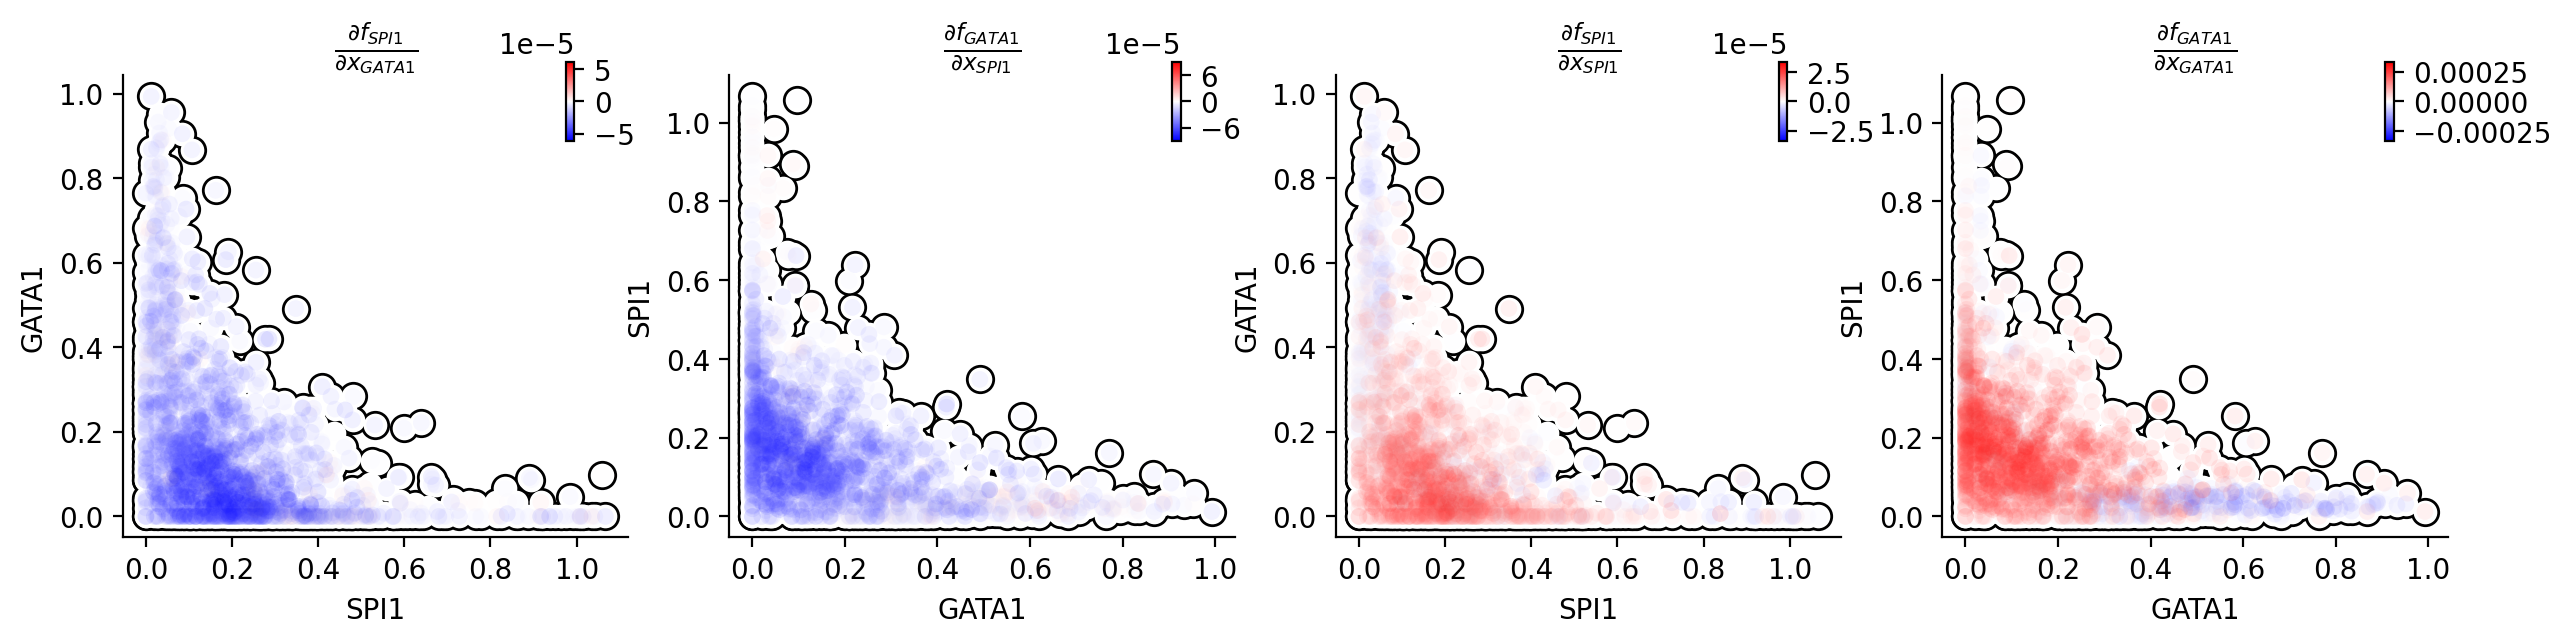

In [6]:
%matplotlib inline

genes = ["SPI1", "GATA1"]

fig, axes = plt.subplots(1, 4, figsize=(15, 3))
dyn.pl.jacobian_on_gene_axis(adata,"GATA1", "SPI1", x_gene="SPI1", y_gene="GATA1", ax=axes[0])
dyn.pl.jacobian_on_gene_axis(adata,"SPI1", "GATA1", x_gene="GATA1", y_gene="SPI1", ax=axes[1])
dyn.pl.jacobian_on_gene_axis(adata,"SPI1", "SPI1", x_gene="SPI1", y_gene="GATA1", ax=axes[2])
dyn.pl.jacobian_on_gene_axis(adata,"GATA1", "GATA1", x_gene="GATA1", y_gene="SPI1",ax=axes[3])
plt.show()

Transforming subset Jacobian: 100%|██████████| 1947/1947 [00:00<00:00, 113957.52it/s]


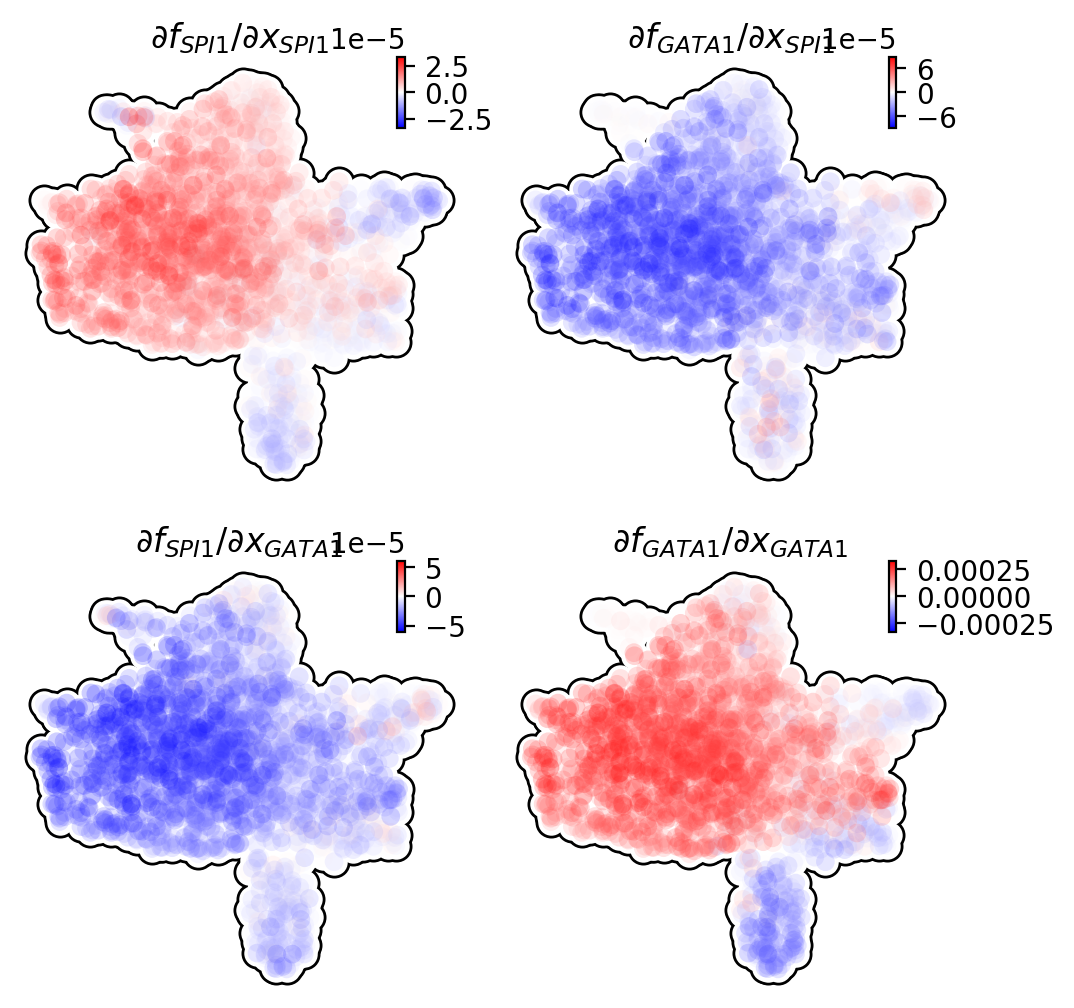

In [7]:
dyn.vf.jacobian(adata,
                regulators = ["SPI1", "GATA1"])
dyn.pl.jacobian(adata, figsize=(3,3),
                regulators = ["SPI1", "GATA1"])

In [19]:
#dyn.configuration.set_pub_style_mpltex()
dyn.pl.style()

Transforming subset Jacobian: 100%|██████████| 1947/1947 [00:00<00:00, 101702.57it/s]


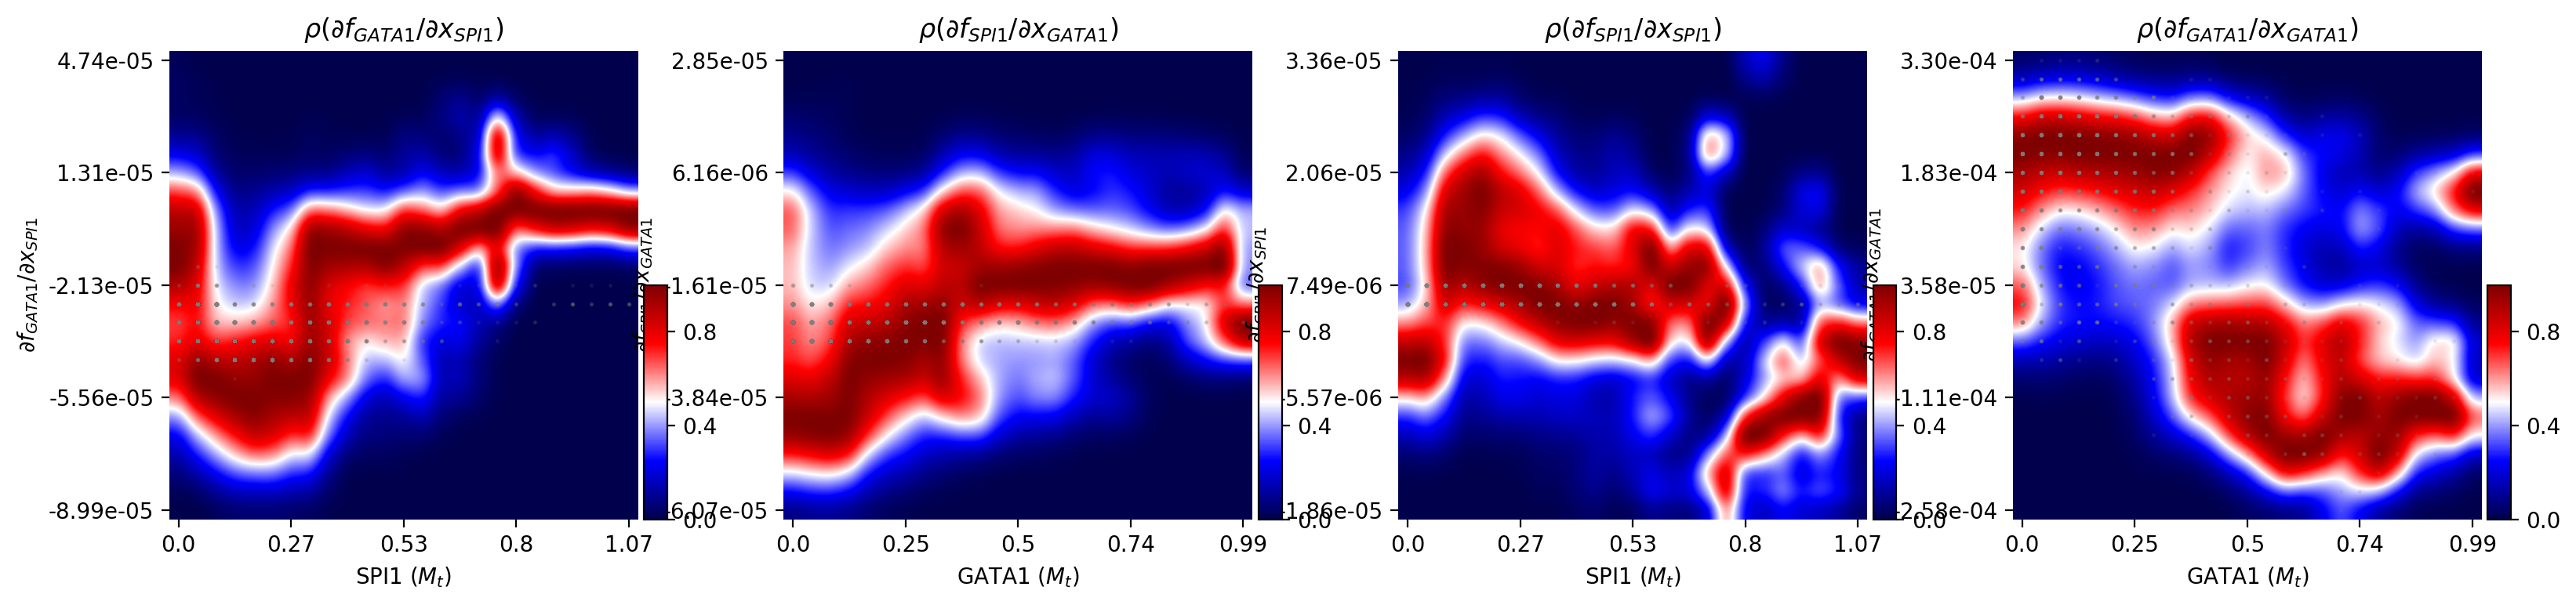

In [10]:
%matplotlib inline

dyn.vf.jacobian(adata, regulators=["SPI1", "GATA1"], 
                effectors=["SPI1", "GATA1"])
#dyn.pl.style()
dyn.pl.response(
    adata,
    np.array([["SPI1", "GATA1"], ["GATA1", "SPI1"], 
              ["SPI1", "SPI1"], ["GATA1", "GATA1"]]),
    ykey="jacobian",
    log=False,
    drop_zero_cells=True,
    grid_num=25,
    figsize=(4, 4),
    save_show_or_return="show",
    cmap='seismic'
)

Saving figure to figures/fig4/scatters_response_['SPI1', 'SPI1']_magma.svg.pdf...
Done


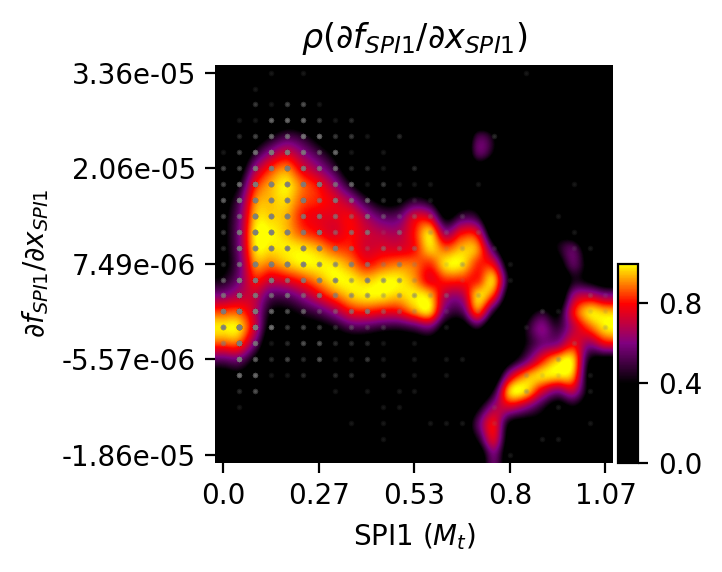

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
#fig,ax=plt.subplots(1,1,figsize = (3,3))
pair=["SPI1", "SPI1"]
fig=dyn.pl.response(
    adata,
    np.array([pair]),
    ykey="jacobian",
    log=False,
    drop_zero_cells=True,
    grid_num=25,
    figsize=(3, 3),
    save_show_or_return='all',#ax=ax,
    #cmap='gist_heat',
    save_kwargs={'path':f'figures/fig4/response_{pair}_magma.svg',
                'dpi':300,'bbox_inches':'tight'}
)
#fig.savefig(f'figures/fig4/response_{pair}.png', dpi=300, bbox_inches='tight')

In [27]:
adata.layers['M_t']

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2527630 stored elements and shape (1947, 1956)>

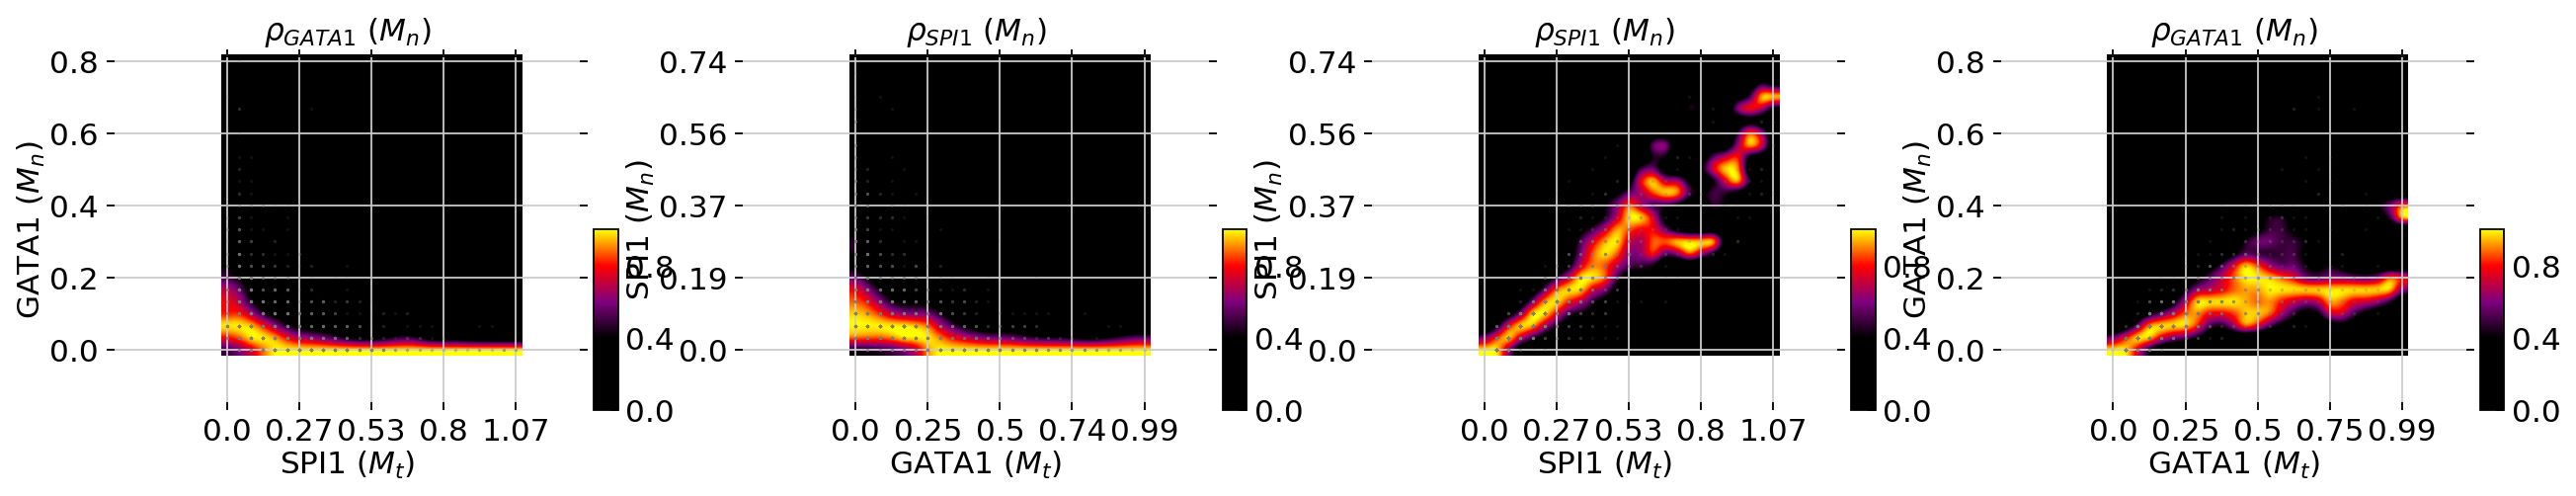

In [22]:
dyn.pl.response(
    adata,
    np.array([["SPI1", "GATA1"], ["GATA1", "SPI1"], 
              ["SPI1", "SPI1"], ["GATA1", "GATA1"]]),
    #ykey="jacobian",
    log=False,
    drop_zero_cells=True,
    grid_num=25,
    figsize=(4, 4),
    save_show_or_return="show"
)